## Adding sqlite database as a checkpointer

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = model.invoke(messages)

    # response store state
    return {'messages': [response]}

In [6]:
conn = sqlite3.connect(database='chatbot.db', check_same_thread=False)
# Checkpointer
checkpointer = SqliteSaver(conn=conn)

In [7]:
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

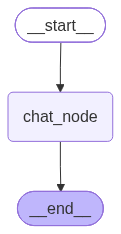

In [8]:
chatbot

In [9]:
initial_state = {
    'messages': [HumanMessage(content='Write a poem by RabindraNath Tagore')]
}

In [10]:
config = {'configurable': {'thread_id': 'thread-1'}}

In [11]:
final_state = chatbot.invoke(initial_state, config=config)


In [12]:
import pprint
pprint.pprint(final_state["messages"][-1].content)

('Here is an original poem inspired by the spirit of Rabindranath '
 'Tagore—lyrical, reflective, and nature-filled:\n'
 '\n'
 '**When the Dawn Opens the Grass**\n'
 '\n'
 'When the dawn opens the grass  \n'
 'with a quiet hand of gold,  \n'
 'the earth remembers  \n'
 'the footsteps of the first light.\n'
 '\n'
 'The river, like a tender thought,  \n'
 'moves beneath the trees,  \n'
 'carrying in its heart  \n'
 'the whisper of unseen birds.\n'
 '\n'
 'I stood where the morning wind  \n'
 'touched the brow of the flowers,  \n'
 'and the silence there was deep  \n'
 'as a prayer not yet spoken.\n'
 '\n'
 'O life, my gentle traveler,  \n'
 'why do you hide your song  \n'
 'in the dark creases of sorrow  \n'
 'and the bright sleeves of joy?\n'
 '\n'
 'The sky does not divide  \n'
 'its blue between tears and laughter;  \n'
 'it holds them both  \n'
 'like the hands of a mother.\n'
 '\n'
 'So let my heart become  \n'
 'a lamp at the window of the world,  \n'
 'burning not to conquer night

In [13]:
final_state

{'messages': [HumanMessage(content='Write a poem by RabindraNath Tagore', additional_kwargs={}, response_metadata={}, id='2a3e0fd8-559a-454e-9787-36f0c365346a'),
  AIMessage(content='Here is an original poem inspired by the spirit of Rabindranath Tagore—lyrical, reflective, and nature-filled:\n\n**When the Dawn Opens the Grass**\n\nWhen the dawn opens the grass  \nwith a quiet hand of gold,  \nthe earth remembers  \nthe footsteps of the first light.\n\nThe river, like a tender thought,  \nmoves beneath the trees,  \ncarrying in its heart  \nthe whisper of unseen birds.\n\nI stood where the morning wind  \ntouched the brow of the flowers,  \nand the silence there was deep  \nas a prayer not yet spoken.\n\nO life, my gentle traveler,  \nwhy do you hide your song  \nin the dark creases of sorrow  \nand the bright sleeves of joy?\n\nThe sky does not divide  \nits blue between tears and laughter;  \nit holds them both  \nlike the hands of a mother.\n\nSo let my heart become  \na lamp at the

In [14]:
initial_state = {
    'messages': [HumanMessage(content='MY Name is Suman')]
}

In [15]:
final_state = chatbot.invoke(initial_state, config=config)
final_state

{'messages': [HumanMessage(content='Write a poem by RabindraNath Tagore', additional_kwargs={}, response_metadata={}, id='2a3e0fd8-559a-454e-9787-36f0c365346a'),
  AIMessage(content='Here is an original poem inspired by the spirit of Rabindranath Tagore—lyrical, reflective, and nature-filled:\n\n**When the Dawn Opens the Grass**\n\nWhen the dawn opens the grass  \nwith a quiet hand of gold,  \nthe earth remembers  \nthe footsteps of the first light.\n\nThe river, like a tender thought,  \nmoves beneath the trees,  \ncarrying in its heart  \nthe whisper of unseen birds.\n\nI stood where the morning wind  \ntouched the brow of the flowers,  \nand the silence there was deep  \nas a prayer not yet spoken.\n\nO life, my gentle traveler,  \nwhy do you hide your song  \nin the dark creases of sorrow  \nand the bright sleeves of joy?\n\nThe sky does not divide  \nits blue between tears and laughter;  \nit holds them both  \nlike the hands of a mother.\n\nSo let my heart become  \na lamp at the

In [16]:
initial_state = {
    'messages': [HumanMessage(content='what is my name bdw')]
}

In [17]:
final_state = chatbot.invoke(initial_state, config=config)
final_state

{'messages': [HumanMessage(content='Write a poem by RabindraNath Tagore', additional_kwargs={}, response_metadata={}, id='2a3e0fd8-559a-454e-9787-36f0c365346a'),
  AIMessage(content='Here is an original poem inspired by the spirit of Rabindranath Tagore—lyrical, reflective, and nature-filled:\n\n**When the Dawn Opens the Grass**\n\nWhen the dawn opens the grass  \nwith a quiet hand of gold,  \nthe earth remembers  \nthe footsteps of the first light.\n\nThe river, like a tender thought,  \nmoves beneath the trees,  \ncarrying in its heart  \nthe whisper of unseen birds.\n\nI stood where the morning wind  \ntouched the brow of the flowers,  \nand the silence there was deep  \nas a prayer not yet spoken.\n\nO life, my gentle traveler,  \nwhy do you hide your song  \nin the dark creases of sorrow  \nand the bright sleeves of joy?\n\nThe sky does not divide  \nits blue between tears and laughter;  \nit holds them both  \nlike the hands of a mother.\n\nSo let my heart become  \na lamp at the